<a href="https://colab.research.google.com/github/ncshin/intro-ml-course-winter2026/blob/main/Datathon%20%233.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
from google.colab import drive

In [ ]:
import pandas as pd
import numpy as np
import warnings
import os
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [ ]:
# Import ML Librariees

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import dataset

# dir = ""  # <-- change to your folder

# dir = "/content/drive/My Drive/MPH/MPH/Winter 2026/5016 Machine Learning/Datathon #3" # Nathan's
# dir = "/content/drive/My Drive/Colab Notebooks/HAD5016/Datathons" # => Urim's
# dir = "/content/drive/My Drive/HAD5016/" #=> Jaclyn's

filename = "Datathon #3 Dataset - HAD7001.csv"  # <-- confirm the file name
in_path = os.path.join(dir, filename)

In [ ]:
df = pd.read_csv(in_path)

In [ ]:
df.head()

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.64,1,Caucasian,F,165.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
4,92056,34377,33,0,19.0,NaN,0,Caucasian,M,188.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma


In [ ]:
column_list = list(df.columns)
print(column_list)

# hospital_death

['encounter_id', 'patient_id', 'hospital_id', 'hospital_death', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'hospital_admit_source', 'icu_admit_source', 'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'readmission_status', 'weight', 'albumin_apache', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_invasive_max', 'd1_

In [ ]:
df[['hepatic_failure']].describe()

,hepatic_failure
count,90998.000000
mean,0.012989
std,0.113229
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
df[['hepatic_failure']].isna().sum()

,0
hepatic_failure,715


In [ ]:
df.isna().sum().sort_index()

,0
age,4228
aids,715
albumin_apache,54379
apache_2_bodysystem,1662
apache_2_diagnosis,1662
...,...
temp_apache,4108
urineoutput_apache,48998
ventilated_apache,715
wbc_apache,22012


# Data Cleaning

In [ ]:
#Check how many visits per patient
df = pd.read_csv(in_path) # Re-load df to ensure 'patient_id' and 'encounter_id' are present

print(f"Total unique patient IDs: {df['patient_id'].nunique()}")
print(f"Total unique visit IDs (encounter_id): {df['encounter_id'].nunique()}")

visits_per_patient = df.groupby('patient_id')['encounter_id'].nunique()
print("\nNumber of unique visits per patient:\n")
print(visits_per_patient)

print(f"\nAverage number of visits per patient: {visits_per_patient.mean():.2f}")
print(f"Maximum number of visits for a single patient: {visits_per_patient.max():.0f}")

Total unique patient IDs: 91713
Total unique visit IDs (encounter_id): 91713

Number of unique visits per patient:

patient_id
1         1
2         1
3         1
4         1
5         1
         ..
131045    1
131047    1
131048    1
131049    1
131051    1
Name: encounter_id, Length: 91713, dtype: int64

Average number of visits per patient: 1.00
Maximum number of visits for a single patient: 1


In [ ]:
#Manually keep only columns represented in APACHE
selected_columns = [
    'hospital_death',
    'age',
    'temp_apache',
    'heart_rate_apache',
    'resprate_apache',
    'ventilated_apache',
    'fio2_apache',
    'pao2_apache',
    'paco2_apache',
    'paco2_for_ph_apache',
    'ph_apache',
    'sodium_apache',
    'urineoutput_apache',
    'creatinine_apache',
    'bun_apache',
    'glucose_apache',
    'albumin_apache',
    'bilirubin_apache',
    'hematocrit_apache',
    'wbc_apache',
    'gcs_eyes_apache',
    'gcs_motor_apache',
    'gcs_verbal_apache',
    'gcs_unable_apache',
    'cirrhosis',
    'hepatic_failure',
    'solid_tumor_with_metastasis',
    'lymphoma',
    'leukemia',
    'immunosuppression',
    'aids',
    'pre_icu_los_days',
    'icu_admit_source',
    'readmission_status',
    'apache_post_operative',
]

# Filter the DataFrame to keep only the selected columns
df_apache = df[selected_columns].copy()

In [ ]:
print(f"Original unique values in 'icu_admit_source': {df_apache['icu_admit_source'].nunique()}")
print(df_apache['icu_admit_source'].value_counts())

# Recode 'icu_admit_source' as numerical variable
df_apache['icu_admit_source_recoded'], unique_categories = pd.factorize(df_apache['icu_admit_source'])

# Print the key
print("\n--- Recoding Key for 'icu_admit_source' ---")
for code, category in enumerate(unique_categories):
    print(f"{category}: {code}")

# Drop the original 'icu_admit_source' column
df_apache = df_apache.drop(columns=['icu_admit_source'])

print("\n'icu_admit_source' has been recoded to numerical values and the original column dropped.")

Original unique values in 'icu_admit_source': 5
icu_admit_source
Accident & Emergency         54060
Operating Room / Recovery    18713
Floor                        15611
Other Hospital                2358
Other ICU                      859
Name: count, dtype: int64

--- Recoding Key for 'icu_admit_source' ---
Floor: 0
Accident & Emergency: 1
Operating Room / Recovery: 2
Other Hospital: 3
Other ICU: 4

'icu_admit_source' has been recoded to numerical values and the original column dropped.


In [ ]:
#Check percent missing for APACHE variables
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

missing_percentages = df_apache.isnull().sum() * 100 / len(df)
missing_percentages = missing_percentages.sort_values(ascending=False)

print("Percentage of Missing Values Per Column (Descending Order):\n")
print(missing_percentages)

pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')

Percentage of Missing Values Per Column (Descending Order):

paco2_apache                   77.271488
paco2_for_ph_apache            77.271488
fio2_apache                    77.271488
ph_apache                      77.271488
pao2_apache                    77.271488
bilirubin_apache               63.386870
albumin_apache                 59.292576
urineoutput_apache             53.425360
wbc_apache                     24.000960
hematocrit_apache              21.674136
bun_apache                     21.002475
creatinine_apache              20.556519
sodium_apache                  20.280658
glucose_apache                 12.033190
age                             4.610033
temp_apache                     4.479191
gcs_verbal_apache               2.072770
gcs_eyes_apache                 2.072770
gcs_motor_apache                2.072770
resprate_apache                 1.345502
gcs_unable_apache               1.130701
heart_rate_apache               0.957334
lymphoma                        0.779

In [ ]:
#Remove columns with >30% missing
print(f"Shape of df_apache before dropping columns: {df_apache.shape}")

#Calculate missing percentages again for df_apache
missing_percentages_apache = df_apache.isnull().sum() * 100 / len(df_apache)

#Identify columns to drop (greater than 30% missing)
columns_to_drop = missing_percentages_apache[missing_percentages_apache > 30].index.tolist()

#Drop the identified columns
df_apache = df_apache.drop(columns=columns_to_drop)

print(f"Shape of df_apache after dropping columns with >30% missing: {df_apache.shape}")

Shape of df_apache before dropping columns: (91713, 35)
Shape of df_apache after dropping columns with >30% missing: (91713, 27)


In [ ]:
#Calculate descriptive statistics for numerical APACHE variables
pd.set_option('display.max_columns', None)
display(df_apache.describe())

,hospital_death,age,temp_apache,heart_rate_apache,resprate_apache,ventilated_apache,sodium_apache,creatinine_apache,bun_apache,glucose_apache,hematocrit_apache,wbc_apache,gcs_eyes_apache,gcs_motor_apache,gcs_verbal_apache,gcs_unable_apache,cirrhosis,hepatic_failure,solid_tumor_with_metastasis,lymphoma,leukemia,immunosuppression,aids,pre_icu_los_days,readmission_status,apache_post_operative,icu_admit_source_recoded
count,91713.000000,87485.000000,87605.000000,90835.000000,90479.000000,90998.000000,73113.000000,72860.000000,72451.00000,80677.000000,71835.000000,69701.000000,89812.000000,89812.000000,89812.000000,90676.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,91713.000000,91713.0,91713.000000,91713.000000
mean,0.086302,62.309516,36.414472,99.707932,25.811007,0.325721,137.966373,1.480014,25.82533,160.326822,32.988739,12.133333,3.465049,5.471195,3.994778,0.009528,0.015693,0.012989,0.020638,0.004132,0.007066,0.026165,0.000857,0.835766,0.0,0.201106,1.110900
std,0.280811,16.775119,0.833496,30.870502,15.106312,0.468646,5.279418,1.525787,20.67298,90.790551,6.873585,6.917984,0.951715,1.288376,1.560166,0.097148,0.124284,0.113229,0.142169,0.064148,0.083763,0.159628,0.029265,2.487756,0.0,0.400829,0.744301
min,0.000000,16.000000,32.100000,30.000000,4.000000,0.000000,117.000000,0.300000,4.00000,39.000000,16.200000,0.900000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-24.947222,0.0,0.000000,-1.000000
25%,0.000000,52.000000,36.200000,86.000000,11.000000,0.000000,135.000000,0.720000,13.00000,97.000000,28.000000,7.500000,3.000000,6.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035417,0.0,0.000000,1.000000
50%,0.000000,65.000000,36.500000,104.000000,28.000000,0.000000,138.000000,0.980000,19.00000,133.000000,33.200000,10.400000,4.000000,6.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.138889,0.0,0.000000,1.000000
75%,0.000000,75.000000,36.700000,120.000000,36.000000,1.000000,141.000000,1.530000,32.00000,196.000000,37.900000,15.100000,4.000000,6.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.409028,0.0,0.000000,1.000000
max,1.000000,89.000000,39.700000,178.000000,60.000000,1.000000,158.000000,11.180000,127.00000,598.700000,51.400000,45.800000,4.000000,6.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,159.090972,0.0,1.000000,4.000000


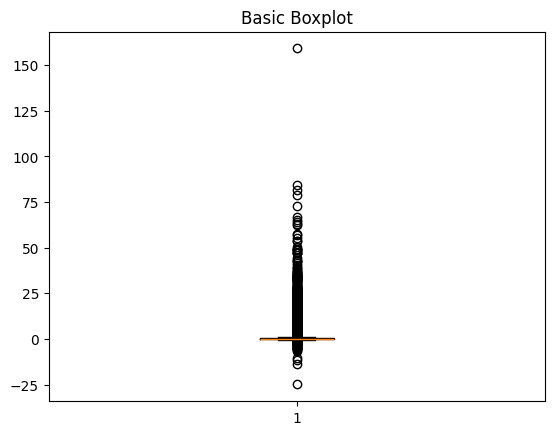

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the box plot
#plt.boxplot(df_apache[['pre_icu_los_days']], notch=True, patch_artist=True) # notch=True adds confidence intervals, patch_artist=True allows coloring

plt.boxplot(df_apache[['pre_icu_los_days']])
plt.title('Basic Boxplot')
plt.show()

In [ ]:
print("\n--- Outlier Detection using Interquartile Range (IQR) Method ---\n")

numerical_cols = df_apache.select_dtypes(include=['number']).columns.tolist()

# Identify binary columns to exclude
binary_cols = []
for col in numerical_cols:
    unique_values = df_apache[col].dropna().unique()
    if len(unique_values) <= 2 and all(val in [0, 1] for val in unique_values):
        binary_cols.append(col)

# Also exclude 'icu_admit_source_recoded' as it's a recoded categorical variable
exclusion_list = binary_cols + ['icu_admit_source_recoded', 'gcs_motor_apache']

# Filter out binary and explicitly excluded columns from the numerical columns list
filtered_numerical_cols = [col for col in numerical_cols if col not in exclusion_list]

for col in filtered_numerical_cols:
    Q1 = df_apache[col].quantile(0.25)
    Q3 = df_apache[col].quantile(0.75)
    IQR = Q3 - Q1

    # Using 3 * IQR as requested for more extreme outliers
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    outliers = df_apache[(df_apache[col] < lower_bound) | (df_apache[col] > upper_bound)][col]

    if not outliers.empty:
        print(f"Column: {col}")
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"  Number of outliers: {len(outliers)}")
        print(f"  Percentage of outliers: {(len(outliers) / len(df_apache[col].dropna()) * 100):.2f}% (relative to non-null values)")
        print(f"  Min Outlier Value: {outliers.min():.2f}, Max Outlier Value: {outliers.max():.2f}\n")

print("\n--- Outlier detection complete ---")


--- Outlier Detection using Interquartile Range (IQR) Method ---

Column: temp_apache
  Q1: 36.20, Q3: 36.70, IQR: 0.50
  Lower Bound: 34.70, Upper Bound: 38.20
  Number of outliers: 4601
  Percentage of outliers: 5.25% (relative to non-null values)
  Min Outlier Value: 32.10, Max Outlier Value: 39.70

Column: creatinine_apache
  Q1: 0.72, Q3: 1.53, IQR: 0.81
  Lower Bound: -1.71, Upper Bound: 3.96
  Number of outliers: 4314
  Percentage of outliers: 5.92% (relative to non-null values)
  Min Outlier Value: 3.97, Max Outlier Value: 11.18

Column: bun_apache
  Q1: 13.00, Q3: 32.00, IQR: 19.00
  Lower Bound: -44.00, Upper Bound: 89.00
  Number of outliers: 1583
  Percentage of outliers: 2.18% (relative to non-null values)
  Min Outlier Value: 89.10, Max Outlier Value: 127.00

Column: glucose_apache
  Q1: 97.00, Q3: 196.00, IQR: 99.00
  Lower Bound: -200.00, Upper Bound: 493.00
  Number of outliers: 889
  Percentage of outliers: 1.10% (relative to non-null values)
  Min Outlier Value: 494

In [ ]:
#Drop outliers
df_apache_nooutliers = df_apache.copy()

numerical_cols = df_apache_nooutliers.select_dtypes(include=['number']).columns.tolist()

# Identify binary columns to exclude (re-using the logic from outlier detection)
binary_cols = []
for col in numerical_cols:
    unique_values = df_apache_nooutliers[col].dropna().unique()
    if len(unique_values) <= 2 and all(val in [0, 1] for val in unique_values):
        binary_cols.append(col)

# Also exclude 'icu_admit_source_recoded' and 'gcs_motor_apache' from outlier removal
exclusion_list = binary_cols + ['icu_admit_source_recoded', 'gcs_motor_apache']

# Filter out binary and explicitly excluded columns from the numerical columns list
filtered_numerical_cols = [col for col in numerical_cols if col not in exclusion_list]

initial_rows = df_apache_nooutliers.shape[0]

for col in filtered_numerical_cols:
    Q1 = df_apache_nooutliers[col].quantile(0.25)
    Q3 = df_apache_nooutliers[col].quantile(0.75)
    IQR = Q3 - Q1

    # Using 3 * IQR for outlier detection (as in previous step)
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    # Filter out outliers for the current column
    df_apache_nooutliers = df_apache_nooutliers[
        (df_apache_nooutliers[col] >= lower_bound) |
        (df_apache_nooutliers[col].isna())]
    df_apache_nooutliers = df_apache_nooutliers[
        (df_apache_nooutliers[col] <= upper_bound) |
        (df_apache_nooutliers[col].isna())]

final_rows = df_apache_nooutliers.shape[0]

print(f"Shape of df_apache before outlier removal: ({initial_rows}, {df_apache.shape[1]}) ")
print(f"Shape of df_apache_nooutliers after outlier removal: ({final_rows}, {df_apache_nooutliers.shape[1]})")
print(f"Number of rows removed: {initial_rows - final_rows}")

Shape of df_apache before outlier removal: (91713, 27) 
Shape of df_apache_nooutliers after outlier removal: (69975, 27)
Number of rows removed: 21738


In [ ]:
#Check class imbalance
hospital_death_percentages = df_apache_nooutliers['hospital_death'].value_counts(normalize=True) * 100
print("Percentage of patients for hospital_death (0=No Death, 1=Death):\n")
print(hospital_death_percentages)

Percentage of patients for hospital_death (0=No Death, 1=Death):

hospital_death
0    93.819221
1     6.180779
Name: proportion, dtype: float64


### Pipeline

**Pipeline order:**
1. Data splitting
2. Crossfold validation
3. Class imbalance (inside each fold)
4. Imputation
5. Normalization (some models)

In [ ]:
#Data splitting
from sklearn.model_selection import train_test_split

X = df_apache_nooutliers[['age', 'temp_apache', 'heart_rate_apache', 'resprate_apache', 'ventilated_apache', 'sodium_apache', 'creatinine_apache', 'bun_apache', 'glucose_apache', 'hematocrit_apache', 'wbc_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache', 'gcs_unable_apache', 'cirrhosis', 'hepatic_failure', 'solid_tumor_with_metastasis', 'lymphoma', 'leukemia', 'immunosuppression', 'aids', 'pre_icu_los_days', 'icu_admit_source_recoded', 'readmission_status', 'apache_post_operative']]
y = df_apache_nooutliers['hospital_death']

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

def train(model, X_train, y_train, X_test, y_test):
    # Fit the model
    model.fit(X_train, y_train)

    # Get predictions
    predictions = model.predict(X_test)

    # Get probability scores for ROC-AUC
    if hasattr(model, "predict_proba"):
        prob_scores = model.predict_proba(X_test)[:, 1]
    else:
        # For models without predict_proba, use decision_function
        prob_scores = model.decision_function(X_test)

    # Calculate standard metrics
    accuracy = accuracy_score(y_test, predictions)
    #Using 'weighted' to handle class imbalance
    precision = precision_score(y_test, predictions, average='weighted', zero_division=0)
    recall = recall_score(y_test, predictions, average='weighted', zero_division=0) # Sensitivity
    f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
    # Calculate Additional Clinical Metrics
    auc = roc_auc_score(y_test, prob_scores)

    print(f"Fold Accuracy:    {accuracy:.4f}")
    print(f"Fold Precision:   {precision:.4f}")
    print(f"Fold Recall: {recall:.4f}")
    print(f"Fold F1-score:    {f1:.4f}")
    print(f"Fold ROC-AUC:     {auc:.4f}")

# K-Fold Cross Validation

In [ ]:
#Define method to use kfold cross-validation with different models
#Include imputation, normalization, and checks for class imbalance within folds
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def crossval(model):
   kf = KFold(n_splits=5, shuffle=True, random_state=42)
   feature_importances_list = []
   for i, (train_index, test_index) in enumerate(kf.split(X)):
        print(f"\n--- Fold {i+1} ---")
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold_all, y_test_fold_all = y.iloc[train_index], y.iloc[test_index]

        # Initialize SimpleImputer
        imputer = SimpleImputer(strategy='mean')

        # Fit imputer on X_train_fold and transform both X_train_fold and X_test_fold
        X_train_imputed = imputer.fit_transform(X_train_fold)
        X_test_imputed = imputer.transform(X_test_fold)

        # Convert imputed arrays back to DataFrames, preserving column names
        X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=X_train_fold.columns, index=X_train_fold.index)
        X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=X_test_fold.columns, index=X_test_fold.index)

        # Initialize StandardScaler
        scaler = StandardScaler()

        # Fit scaler on X_train_imputed_df and transform both X_train_imputed_df and X_test_imputed_df
        X_train_scaled = scaler.fit_transform(X_train_imputed_df)
        X_test_scaled = scaler.transform(X_test_imputed_df)

        # Convert scaled arrays back to DataFrames
        X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_imputed_df.columns, index=X_train_imputed_df.index)
        X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_imputed_df.columns, index=X_test_imputed_df.index)

        y_train_target = y_train_fold_all
        y_test_target = y_test_fold_all

        print(f"\nProcessing target: {y_train_target.name}")
        if isinstance(model, LogisticRegression):
            print(f"  Model: {model.__class__.__name__} (penalty={model.penalty}, C={model.C})")
        else:
            print(f"  Model: {model.__class__.__name__}")
        print("Class distribution in training fold:")
        print(y_train_target.value_counts(normalize=True))

        print("Class distribution in test fold:")
        print(y_test_target.value_counts(normalize=True))

        if y_train_target.nunique() == 1:
            print(f"Skipping training for {y_train_target.name} as training data has only one class.")
            continue

        new_model_instance = type(model)(**model.get_params())
        train(new_model_instance, X_train_scaled_df, y_train_target, X_test_scaled_df, y_test_target)

        if hasattr(new_model_instance, 'feature_importances_'):
            feature_importances_list.append(pd.Series(new_model_instance.feature_importances_, index=X_train_scaled_df.columns))

   if feature_importances_list:
       avg_feature_importances = pd.concat(feature_importances_list, axis=1).mean(axis=1).sort_values(ascending=False)
       print(f"\n--- Average Feature Importances for {model.__class__.__name__} across folds ---")
       print(avg_feature_importances)
       return avg_feature_importances
   return None

## Random Forest - XG Boost

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = [
    #LogisticRegression(penalty='l1', C=1.0, random_state=42, max_iter=1000, solver='liblinear'),
    #LogisticRegression(penalty='l2', C=1.0, random_state=42, max_iter=1000, solver='liblinear'),
    RandomForestClassifier(random_state=42, n_estimators=100),
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), # Added XGBoost
    #SVC(kernel='linear', random_state=42)
]
for model_instance in models:
    print(f"\nTraining {model_instance.__class__.__name__}...")
    crossval(model_instance)


Training RandomForestClassifier...

--- Fold 1 ---

Processing target: hospital_death
  Model: RandomForestClassifier
Class distribution in training fold:
hospital_death
0    0.938478
1    0.061522
Name: proportion, dtype: float64
Class distribution in test fold:
hospital_death
0    0.937049
1    0.062951
Name: proportion, dtype: float64
Fold Accuracy:    0.9398
Fold Precision:   0.9243
Fold Recall: 0.9398
Fold F1-score:    0.9177
Fold ROC-AUC:     0.8437

--- Fold 2 ---

Processing target: hospital_death
  Model: RandomForestClassifier
Class distribution in training fold:
hospital_death
0    0.937889
1    0.062111
Name: proportion, dtype: float64
Class distribution in test fold:
hospital_death
0    0.939407
1    0.060593
Name: proportion, dtype: float64
Fold Accuracy:    0.9421
Fold Precision:   0.9270
Fold Recall: 0.9421
Fold F1-score:    0.9213
Fold ROC-AUC:     0.8331

--- Fold 3 ---

Processing target: hospital_death
  Model: RandomForestClassifier
Class distribution in training 

In [ ]:
#Hyperparameter tuning using grid search (Tutorial 6.1)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier

# Define the model
model = RandomForestClassifier(random_state=42) # Changed to RandomForestClassifier

# Define the hyperparameter values that should be tested for RandomForestClassifier
param_dist = {
    "n_estimators": [50, 100, 200], # Number of trees in the forest
    "max_depth": [10, 20, 30, None], # Maximum depth of the tree (None means unlimited)
    "min_samples_leaf": [1, 2, 4], # Minimum number of samples required to be at a leaf node
    "max_features": ['sqrt', 'log2'] # Number of features to consider when looking for the best split
}

# Setting up Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=5)

# Initialize Grid Search with the model and the hyperparameters to search
hp_search = GridSearchCV(
    model,
    param_grid=param_dist,
    cv=skf,
    scoring='accuracy'
)

# Train Grid Search on the training data
hp_search.fit(X_train, y_train)

# Extract results into a DataFrame
results = pd.DataFrame(hp_search.cv_results_)

# Display the set of parameters that achieved the best score
results[results['rank_test_score'] == 1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
40,12.775848,0.126981,0.178003,0.003063,30,sqrt,2,100,"{'max_depth': 30, 'max_features': 'sqrt', 'min...",0.94246,0.942264,0.941692,0.941311,0.942359,0.942017,0.000442,1


## Neural Networks

## Todo

*   Revisit outliers
*   Try neural networks
*   Hyperparameter tuning
*   Fit final model and visualizations





